# STEP 4 · 参数敏感性

对 `d0 / γ / u / β / C_BAR / P_DEAD` 六参数敏感性测试。
输出 M 总值与 access/crowd/reach 三项分解。

预期方向：u/β 调大→M_crowd 升；γ 调大→拥挤缓和；d0 调大→M_access 升而单站拥挤缓和；C_BAR 调大→可达覆盖率不减。

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cso, style
style.set_nature()

CITY = 'guangzhou'
CITY_CONFIG = ''
MODE = 'truncated'
NOTEBOOK_SMOKE = False     # True=少抽样/少天数/小候选，先快速跑通链路（不改参数语义）

cso.configure_city(CITY, CITY_CONFIG or None)
DRAWS = 5 if NOTEBOOK_SMOKE else cso.N_ENSEMBLE
OUT = cso.OUTPUT_ROOT / cso.CITY / 'notebook_step4'
OUT.mkdir(parents=True, exist_ok=True)
print(f'城市 {cso.CITY_NAME}({cso.CITY}) | 口径 {MODE} | 抽样 {DRAWS} | 发现 {len(cso.DAYS)} 天')
print('比例 S1:', cso.ADD_FRACS, '| S2:', cso.REMOVE_FRACS, '| S3:', cso.SWAP_FRACS)
print('图件输出目录:', OUT)

城市 广州(guangzhou) | 口径 truncated | 抽样 40 | 发现 7 天
比例 S1: (0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5) | S2: (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9) | S3: (0.01, 0.05, 0.1, 0.2, 0.3)
图件输出目录: D:\Desktop\香港大学\20260521 根据网约车轨迹优化充电站\ChargingStationOptimization\Outputs\guangzhou\notebook_step4


## 4.1 基准存量 + 固定需求面 + 距离矩阵

In [2]:
D = cso.build_demand_surface(draws=DRAWS)
w = D['w']
st = cso.load_stations(MODE)
slon, slat = st['lon'].to_numpy(), st['lat'].to_numpy()
fast, slow = st['fast'].to_numpy(), st['slow'].to_numpy()
c = cso.dist_matrix(D['lon_c'], D['lat_c'], slon, slat)
print(f'{cso.CITY_NAME} · {MODE}: 站点 {len(st)} | 需求节点 {D["n_cells"]} | 事件合计 {w.sum():.0f}')
print('扫描网格:', {k: v for k, v in cso.SENS_GRID.items()})

[OSMnx] 载入缓存路网图 _graph_guangzhou.graphml ...
[OSMnx] 路网图就绪：75,488 节点，166,968 边


需求面·7天×40抽样(路网节点中心):   0%|          | 0/7 [00:00<?, ?it/s]

[路网] 把 42450 需求点 + 873 站点 snap 到路网节点...


scipy最短路·738个站点节点(cutoff 100km):   0%|          | 0/12 [00:00<?, ?it/s]

广州 · truncated: 站点 873 | 需求节点 42450 | 事件合计 4598
扫描网格: {'d0': (3, 5, 8, 12, 15), 'gamma': (5, 8, 10, 15), 'u': (0.8, 1.0, 1.2, 1.5), 'beta': (0.5, 1.0, 1.5, 2.0), 'C_BAR': (60, 80, 100, 120), 'P_DEAD': (250, 500, 1000, 2000)}


## 4.2 单参数扫描表

In [3]:
df = cso.run_sensitivity(w, c, fast, slow)
show = df.copy()
for cc in ['M', 'M_access', 'M_crowd', 'M_reach']:
    show[cc] = show[cc].round(0)
show['reach_cov'] = show['reach_cov'].round(3)
display(show)

,param,value,M,M_access,M_crowd,M_reach,reach_cov,over_cap
0,d0,3.0,90097.0,28877.0,8213.0,53007.0,0.988,297
1,d0,5.0,98700.0,39209.0,6483.0,53007.0,0.988,233
2,d0,8.0,113950.0,55638.0,5305.0,53007.0,0.988,263
3,d0,12.0,132965.0,76050.0,3908.0,53007.0,0.988,299
4,d0,15.0,146866.0,90999.0,2859.0,53007.0,0.988,310
5,gamma,5.0,113629.0,55315.0,5307.0,53007.0,0.988,274
6,gamma,8.0,113856.0,55544.0,5305.0,53007.0,0.988,265
7,gamma,10.0,113950.0,55638.0,5305.0,53007.0,0.988,263
8,gamma,15.0,114097.0,55785.0,5304.0,53007.0,0.988,260
9,u,0.8,112949.0,55638.0,4304.0,53007.0,0.988,176


## 4.3 六参数敏感性测试可视化

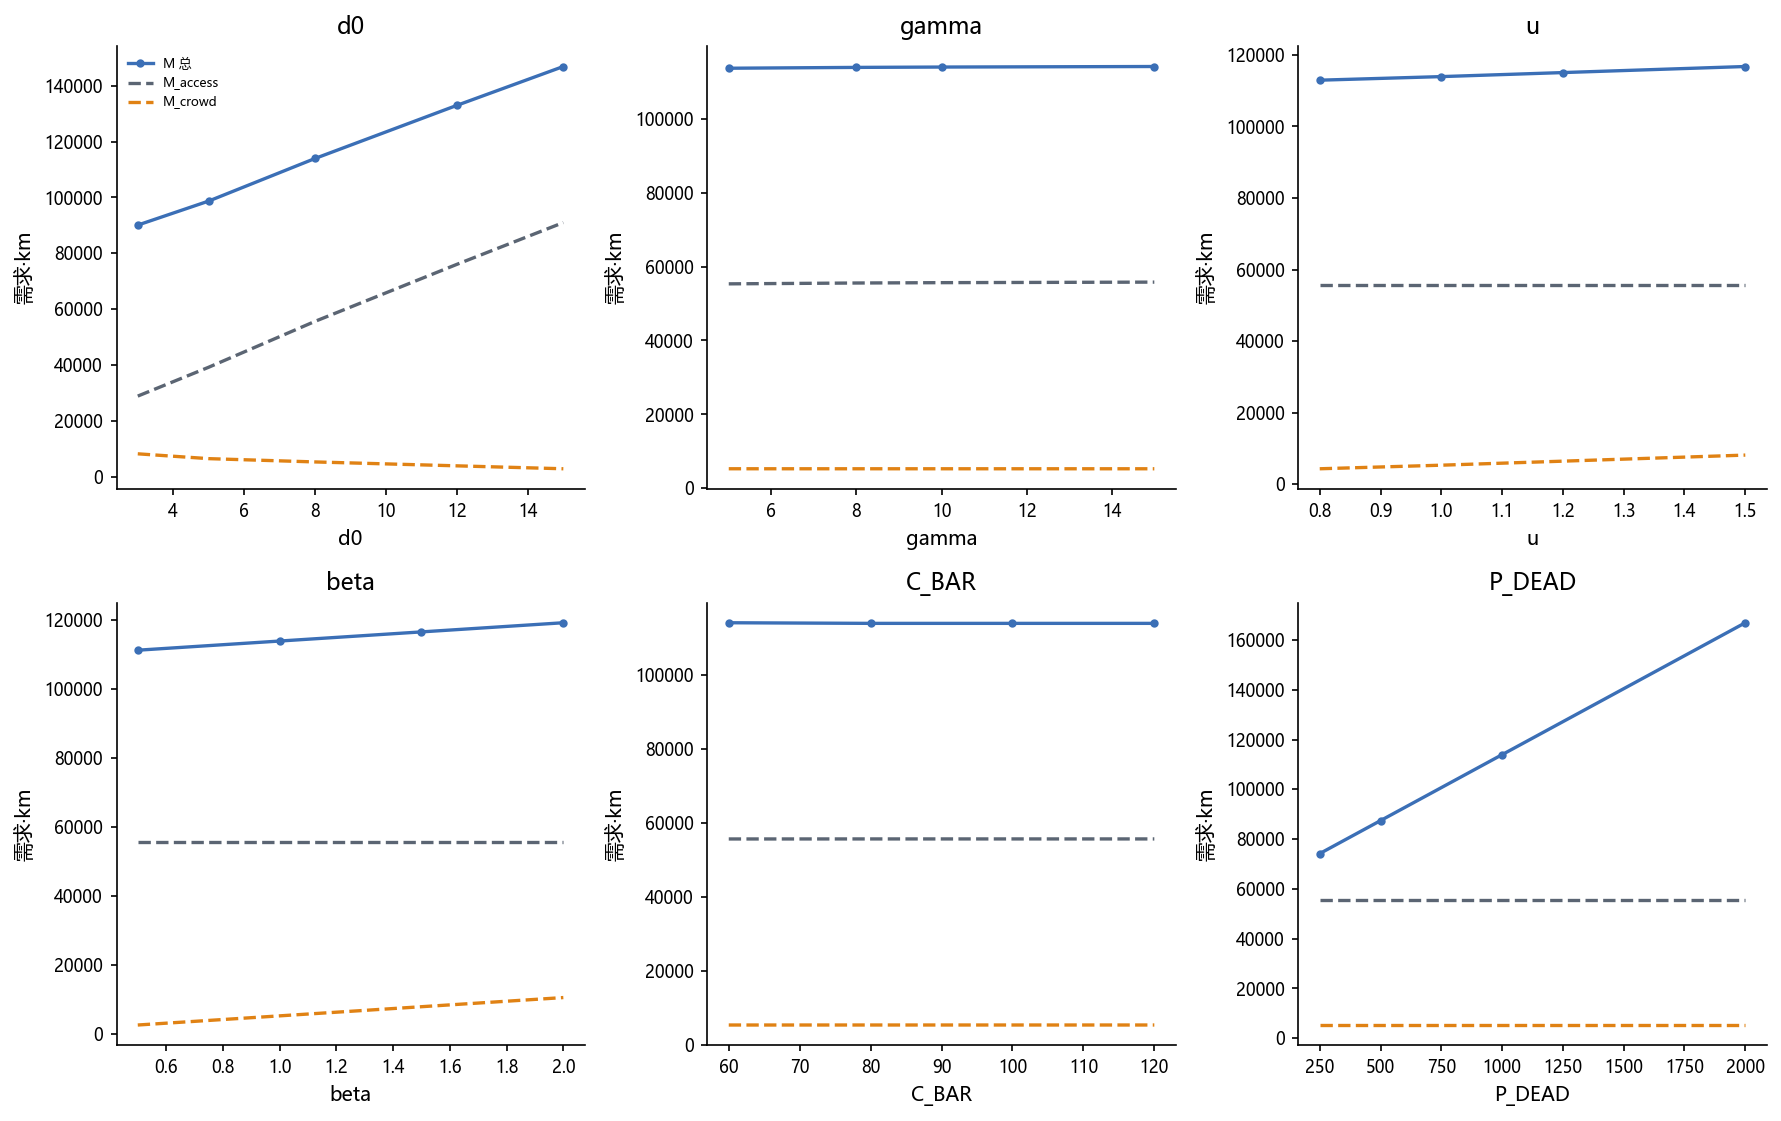

In [4]:
params = list(cso.SENS_GRID)
fig, axes = plt.subplots(2, 3, figsize=style.mm(190, 120))
for p, axi in zip(params, axes.ravel()):
    sub = df[df.param == p].sort_values('value')
    axi.plot(sub['value'], sub['M'], '-o', ms=3, color=style.C['blue'], label='M 总')
    axi.plot(sub['value'], sub['M_access'], '--', color=style.C['gray'], label='M_access')
    axi.plot(sub['value'], sub['M_crowd'], '--', color=style.C['orange'], label='M_crowd')
    axi.set_title(p); axi.set_xlabel(p); axi.set_ylabel('需求·km')
axes.ravel()[0].legend(fontsize=6)
plt.tight_layout(); style.savefig(fig, OUT / 'fig_sensitivity_small_multiples.png'); plt.show()